In [ ]:
!pip install ultralytics==8.3.148 -q
!pip install albumentations==1.4.0 -q
!pip install seaborn -q

In [ ]:
import os
import cv2
import yaml
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

warnings.filterwarnings("ignore")

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

# Fix Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Seed Fixed:", SEED)

In [ ]:
from sklearn.model_selection import train_test_split
import shutil
from glob import glob

# Dataset Paths
IMAGE_DIR = "/kaggle/input/datasets/makmudulhasanrabbi/road-surface-damage-datasetrsdd/data/images"
LABEL_DIR = "/kaggle/input/datasets/makmudulhasanrabbi/road-surface-damage-datasetrsdd/data/labels-YOLO"

# Output
OUTPUT_DIR = "/kaggle/working/road_damage_dataset"

# Create YOLO Folder Structure
for split in ["train", "val", "test"]:
    os.makedirs(f"{OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/labels/{split}", exist_ok=True)

# Get Image Files
image_files = []
for ext in ["*.jpg", "*.png", "*.jpeg"]:
    image_files.extend(glob(os.path.join(IMAGE_DIR, ext)))

print("Total Images:", len(image_files))

# 70% / 15% / 15%
train_files, temp_files = train_test_split(
    image_files, test_size=0.30, random_state=42, shuffle=True
)
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, random_state=42, shuffle=True
)

print(f"Train: {len(train_files)}")
print(f"Validation: {len(val_files)}")
print(f"Test: {len(test_files)}")

# Copy Files
def copy_files(file_list, split_name):
    for img_path in file_list:
        file_name = os.path.basename(img_path)
        label_name = os.path.splitext(file_name)[0] + ".txt"
        label_path = os.path.join(LABEL_DIR, label_name)

        shutil.copy(img_path, os.path.join(OUTPUT_DIR, f"images/{split_name}", file_name))

        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(OUTPUT_DIR, f"labels/{split_name}", label_name))

copy_files(train_files, "train")
copy_files(val_files, "val")
copy_files(test_files, "test")

print("Dataset split completed successfully")

In [ ]:
DATASET_ROOT = "/kaggle/working/road_damage_dataset"

CLASS_NAMES = {
    0: "pothole",
    1: "crack",
    2: "manhole",
}

data_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created successfully")

In [ ]:
from glob import glob

CLASS_NAMES_LIST = ["pothole", "crack", "manhole"]
DATASET_ROOT = "/kaggle/working/road_damage_dataset"

splits = {
    "Train": "labels/train",
    "Validation": "labels/val",
    "Test": "labels/test"
}

total_counts = {0: 0, 1: 0, 2: 0}

for split_name, split_path in splits.items():
    counts = {0: 0, 1: 0, 2: 0}
    for file in glob(os.path.join(DATASET_ROOT, split_path, "*.txt")):
        with open(file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    counts[cls] += 1
                    total_counts[cls] += 1

    plt.figure(figsize=(6, 4))
    plt.bar(CLASS_NAMES_LIST, counts.values())
    plt.title(f"{split_name} Distribution")
    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

plt.figure(figsize=(6, 4))
plt.bar(CLASS_NAMES_LIST, total_counts.values())
plt.title("Overall Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print(total_counts)

In [ ]:
p2_model_yaml = """
nc: 3

scales:
  s: [0.33, 0.50, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]

  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]

  - [-1, 1, SPPF, [1024, 5]]

head:

  # P5 -> P4
  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  # P4 -> P3
  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]

  # P3 -> P2
  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 2], 1, Concat, [1]]
  - [-1, 3, C2f, [128]]

  # P2 -> P3
  - [-1, 1, Conv, [128, 3, 2]]
  - [[-1, 15], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]

  # P3 -> P4
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  # P4 -> P5
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]

  # Detect (4 scales: P2, P3, P4, P5)
  - [[18, 21, 24, 27], 1, Detect, [nc]]
"""

with open("yolov8s_p2.yaml", "w") as f:
    f.write(p2_model_yaml)

print("YOLOv8s+P2 YAML Saved")

In [ ]:
model = YOLO("yolov8s_p2.yaml")
model.load("yolov8s.pt")
print("Pretrained weights loaded")

results = model.train(
    data="data.yaml",

    # Core Training
    epochs=150,
    imgsz=1024,
    batch=12,
    device=0,

    # Optimizer
    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=8,
    cos_lr=True,
    patience=50,
    pretrained=True,

    # Augmentation (conservative — P2 head already boosts recall)
    mosaic=0.85,
    close_mosaic=15,
    mixup=0.05,
    copy_paste=0.0,
    degrees=2.0,
    translate=0.15,
    scale=0.4,
    fliplr=0.5,
    flipud=0.0,
    erasing=0.1,

    # Lighting
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    # Performance
    cache=True,
    amp=True,
    workers=4,
    deterministic=False,

    # Output
    project="RoadDamage",
    name="YOLOv8s_P2"
)

print("Training Completed")

In [19]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2004.0±768.5 MB/s, size: 91.6 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:09<00:00,  2.07it/s]


                   all        301        715      0.645      0.516      0.554      0.254
               pothole        115        185      0.593      0.384      0.452      0.196
                 crack        205        383      0.525      0.371      0.388      0.131
               manhole        117        147      0.818      0.793      0.823      0.436
Speed: 1.6ms preprocess, 22.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x799874457e30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    

In [20]:
results = model.predict(
    source=os.path.join(DATASET_ROOT, "images/test"),
    save=True,
    conf=0.25
)
print("Prediction Completed")

Results saved to runs/detect/predict
Prediction Completed


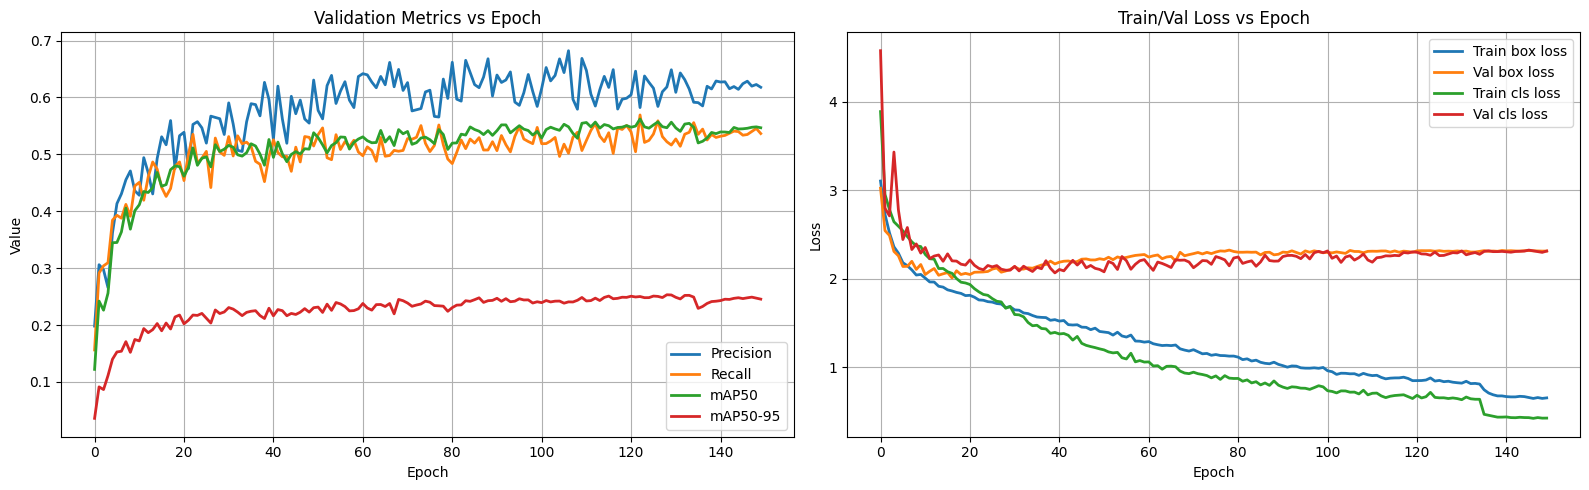

In [21]:
results_csv = "/kaggle/working/RoadDamage/YOLOv8s_P2/results.csv"
df = pd.read_csv(results_csv)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df["metrics/precision(B)"], label="Precision", linewidth=2)
axes[0].plot(df["metrics/recall(B)"], label="Recall", linewidth=2)
axes[0].plot(df["metrics/mAP50(B)"], label="mAP50", linewidth=2)
axes[0].plot(df["metrics/mAP50-95(B)"], label="mAP50-95", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Value")
axes[0].set_title("Validation Metrics vs Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df["train/box_loss"], label="Train box loss", linewidth=2)
axes[1].plot(df["val/box_loss"], label="Val box loss", linewidth=2)
axes[1].plot(df["train/cls_loss"], label="Train cls loss", linewidth=2)
axes[1].plot(df["val/cls_loss"], label="Val cls loss", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Train/Val Loss vs Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Total Images Found: 21


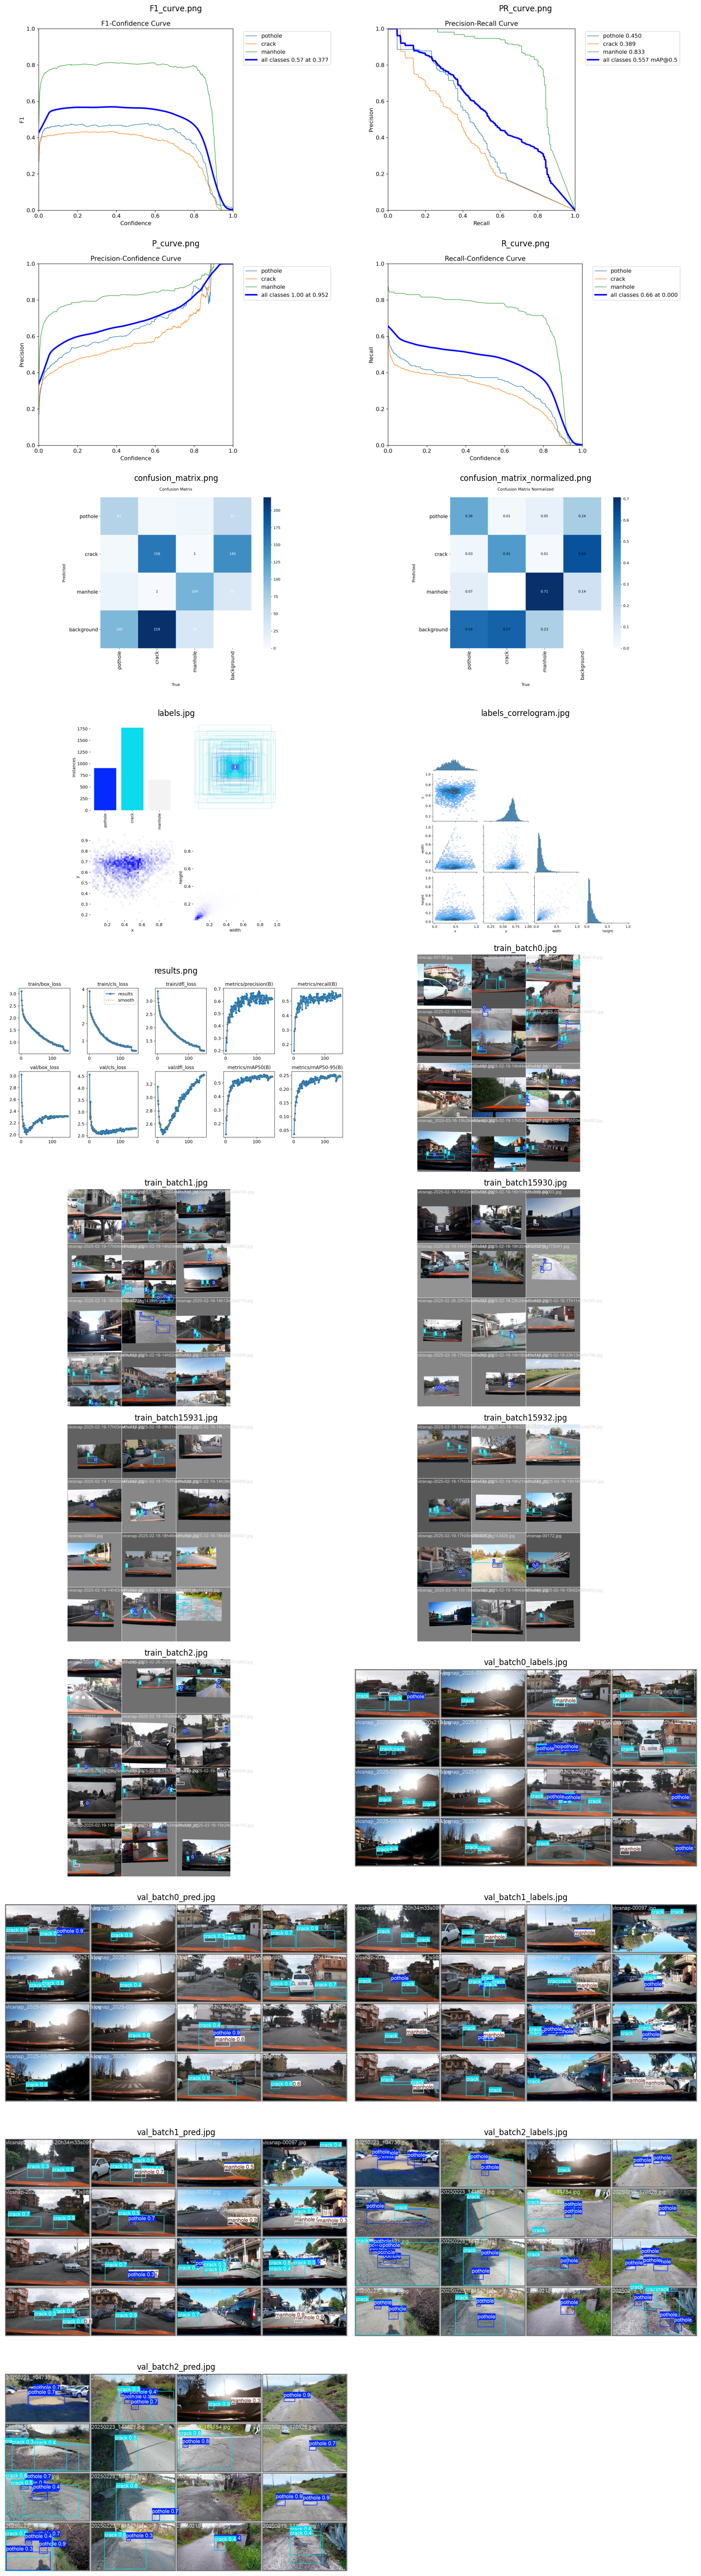

In [22]:
import math
import matplotlib.image as mpimg

folder_path = "/kaggle/working/RoadDamage/YOLOv8s_P2"

image_files = [
    f for f in os.listdir(folder_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]
image_files.sort()

print("Total Images Found:", len(image_files))

cols = 2
rows = math.ceil(len(image_files) / cols)

plt.figure(figsize=(15, rows * 5))
for idx, image_name in enumerate(image_files):
    image_path = os.path.join(folder_path, image_name)
    img = mpimg.imread(image_path)
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Ultralytics 8.3.148 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s_p2 summary (fused): 90 layers, 10,627,228 parameters, 0 gradients, 36.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1740.1±333.0 MB/s, size: 90.1 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:08<00:00,  2.20it/s]


                   all        301        715      0.645      0.516      0.554      0.254
               pothole        115        185      0.593      0.384      0.452      0.196
                 crack        205        383      0.525      0.371      0.388      0.131
               manhole        117        147      0.818      0.793      0.823      0.436
Speed: 1.6ms preprocess, 20.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val3

Per-Class AP
pothole   : 0.1965
crack     : 0.1307
manhole   : 0.4356


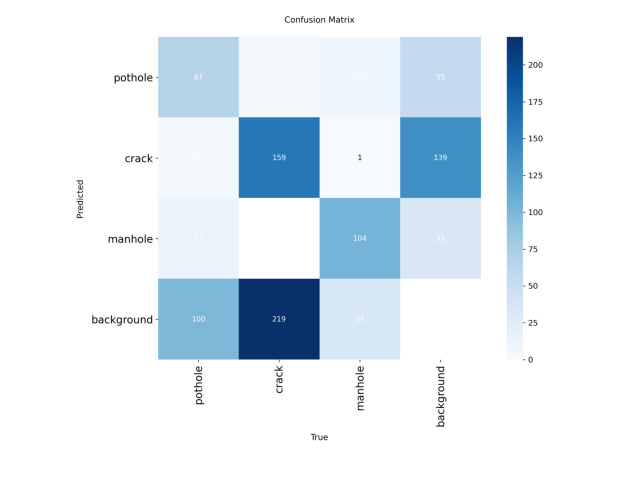

Precision        : 0.6453
Recall           : 0.5159
F1 Score         : 0.5734
mAP@0.5          : 0.5539
mAP@0.5:0.95     : 0.2542
FPS              : 49.01
Latency          : 20.41 ms
Total Parameters : 10,627,228
Trainable Params : 0
YOLOv8s_p2 summary (fused): 90 layers, 10,627,228 parameters, 0 gradients, 36.6 GFLOPs


(90, 10627228, 0, 36.6290944)

In [23]:
from ultralytics import YOLO
from ultralytics.utils.torch_utils import model_info
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import time
import os

best_model = "/kaggle/working/RoadDamage/YOLOv8s_P2/weights/best.pt"
model = YOLO(best_model)

results = model.val(plots=True)

precision = results.box.mp
recall = results.box.mr
map50 = results.box.map50
map5095 = results.box.map
f1 = 2 * precision * recall / (precision + recall + 1e-16)

print("\nPer-Class AP")
for i, ap in enumerate(results.box.maps):
    print(f"{model.names[i]:10s}: {ap:.4f}")

total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(
    p.numel() for p in model.model.parameters()
    if p.requires_grad
)

image_path = "/kaggle/working/road_damage_dataset/images/val/20250219_164714.jpg"
image = cv2.imread(image_path)

for _ in range(20):
    model.predict(image, verbose=False)

runs = 100

start = time.time()
for _ in range(runs):
    model.predict(image, verbose=False)
end = time.time()

fps = runs / (end - start)
latency = 1000 / fps

cm_path = os.path.join(results.save_dir, "confusion_matrix.png")

if os.path.exists(cm_path):
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(cm_path))
    plt.axis("off")
    plt.show()

print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"mAP@0.5          : {map50:.4f}")
print(f"mAP@0.5:0.95     : {map5095:.4f}")
print(f"FPS              : {fps:.2f}")
print(f"Latency          : {latency:.2f} ms")
print(f"Total Parameters : {total_params:,}")
print(f"Trainable Params : {trainable_params:,}")

model_info(model.model)

In [18]:
import os
import zipfile

# Notebook: yolov8s-p2-head  (YOLOv8s + P2 Head)

base = "/kaggle/working"

items = [       # train output (YOLOv8s_P2_Balanced)
    "runs",
    "RoadDamage",             # runs/detect/... + predict outputs
    "yolov8s_p2.yaml",  # model config
    "data.yaml",
    "yolov8s.pt"
]

zip_path = "/kaggle/working/yolov8s_p2_outputs_new.zip"

print("Creating ZIP...")
print("Destination:", zip_path)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as z:

    for item in items:

        path = os.path.join(base, item)

        if not os.path.exists(path):
            print("SKIP - not found:", item)
            continue

        if os.path.isfile(path):
            z.write(path, arcname=item)
            print("Added:", item)

        elif os.path.isdir(path):
            for root, dirs, files in os.walk(path):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname = os.path.relpath(full_path, base)

                    z.write(full_path, arcname=arcname)

            print("Added folder:", item)

print("\nZIP CREATED SUCCESSFULLY!")

size = os.path.getsize(zip_path) / (1024**3)

print(f"ZIP size: {size:.3f} GB")
print("Path:", zip_path)

Creating ZIP...
Destination: /kaggle/working/yolov8s_p2_outputs_new.zip
Added folder: runs
Added folder: RoadDamage
Added: yolov8s_p2.yaml
Added: data.yaml
Added: yolov8s.pt

ZIP CREATED SUCCESSFULLY!
ZIP size: 0.095 GB
Path: /kaggle/working/yolov8s_p2_outputs_new.zip
